# Dette er en jupyter notebook i jupyterlab.

Det er gjort mulig med binder og github. lenger ned på siden har jeg skrevet en guide som forteller hvordan du kan bruke github.com og mybinder.org. I en jupyter notebook kjører du koden i en celle her i nettlesern på en maskin i skyen. Klikk i en celle med kode, **hold nede shift og bruk enter-tasten** for å kjøre koden. 


Her er et eksempel på bruk av bibliotekene [numpy](https://numpy.org/doc/stable/user/absolute_beginners.html), [pandas](https://pandas.pydata.org/docs/user_guide/index.html), [matplotlib](https://matplotlib.org/stable/users/getting_started/#) og [scipy modulen stats (spesifikt funksjonen linregress())](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html) til å plotte en graf. Det er først og fremst en demonstrasjon av de bibliotekene, men koden kjører her i en [jupyter notebook i jupyter lab](https://docs.jupyter.org/en/latest/) og eksempelet bruker [ipywidgets](https://ipywidgets.readthedocs.io/en/stable/) og [Ipython.display](https://ipython.readthedocs.io/en/9.0.2/api/generated/IPython.display.html) for interaktivitet i analogi til pythonkoden som kan kjøres på egen datamaskin der en heller bruker feks [tkinter](https://docs.python.org/3/library/tkinter.html). Her er også litt grunnleggende statistikk.
Jeg fortsetter på engelsk fordi det er så mange engelske ord i python og spesialtegnene er enklere å finne på amerikansk tastaturlayout. The code attempts to follow several python coding style conventions although much of this is suggested by formatter tools in the editor:
- "Knuth's style of breaking in code"
- np for numpy
- pd for pandas
- plt for pyplot from matplotlib
- snake_case
- SCREAMING_SNAKE_CASE
- unpacking variables is neat but can lead to long lines, so compromises where made
- f-strings for printing
- [Selected recommendations from the PEP 8 style guide](https://peps.python.org/pep-0008/) 
    - trailing comma
    - imports
    - whitespace
    - line length
    - line continuation by enclosed parentheses rather than trailing \
    - hanging indents

Button(description='Generate and Display Graph', style=ButtonStyle())

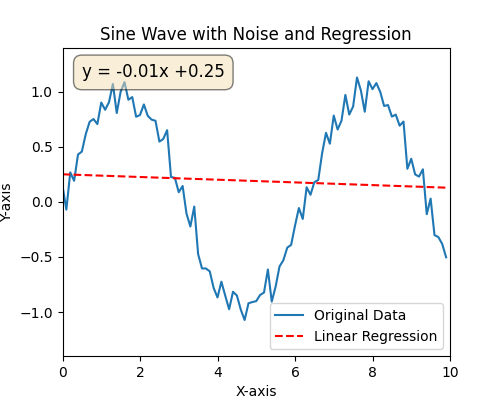

In [1]:
import ipywidgets as widgets
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import scipy.stats as stats

def draw_plot(b):
    
    GRAPH_DATA = {min: 0,max: 10}
    GRAPH_MEAN = 0
    GRAPH_DATA_STEP = 0.1
    GRAPH_STD = GRAPH_DATA_STEP
    EMPIRICAL_Y_LIM = {min: (-4 * GRAPH_STD) 
                       + min(np.sin(np.arange(
                           GRAPH_DATA[min],
                           GRAPH_DATA[max],
                           GRAPH_DATA_STEP,
                           ))),
                       max: (4 * GRAPH_STD) 
                       + max(np.sin(np.arange(
                           GRAPH_DATA[min],
                           GRAPH_DATA[max],
                           GRAPH_DATA_STEP,
                           )))
                      }
    data = {
        'X': np.arange(
            GRAPH_DATA[min], 
            GRAPH_DATA[max], 
            GRAPH_DATA_STEP,
            ),
        'Y': np.sin(np.arange(
            GRAPH_DATA[min], 
            GRAPH_DATA[max], 
            GRAPH_DATA_STEP,
            )) 
        + np.random.normal(
            GRAPH_MEAN, 
            GRAPH_STD, 
            len(np.arange(
                GRAPH_DATA[min], 
                GRAPH_DATA[max], 
                GRAPH_DATA_STEP,
                )))
        }

    df = pd.DataFrame(data)

    (
        slope, 
        intercept, 
        r_value, 
        p_value, 
        std_err,
    ) = stats.linregress(df['X'], df['Y'])
    regression_line = slope * df['X'] + intercept
    formula_text = f'y = {slope:.2f}x {intercept:+.2f}'

    ax.clear()
    ax.plot(df['X'], df['Y'], label=f'Original Data')
    ax.plot(df['X'],
            regression_line,
            color='red',
            linestyle='--',
            label=f'Linear Regression')
    ax.set_title(f'Sine Wave with Noise and Regression')
    ax.set_xlabel(f'X-axis')
    ax.set_ylabel(f'Y-axis')
    ax.legend()
    ax.set_xlim(GRAPH_DATA[min], GRAPH_DATA[max])
    ax.set_ylim(EMPIRICAL_Y_LIM[min], EMPIRICAL_Y_LIM[max])
    ax.text(0.05, 
            0.95, 
            formula_text, 
            transform=ax.transAxes,
            fontsize=12,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5',
                      fc='wheat',
                      alpha=0.5))
    
    fig.canvas.draw()

%matplotlib widget

fig, ax = plt.subplots(figsize = (5,4))
ax.set_title(f'Here is the button you click')

plot_button = widgets.Button(description = (
    f'Generate and Display Graph'
    ))
plot_button.on_click(draw_plot)
display(plot_button)

draw_plot(None)

Du trenger:
- en epost
- en konto på github.com
- gh-cli (installeres)
- git (er som regel installert)
- editor (vim er som regel installert)
- ssh-nøkler lages med ssh-keygen (er som regel installert)
- terminal (med shell som regel er bash eller zsh)

Koden lenger opp på siden er skrevet på min egen maskin der jeg bruker git for versjonskontroll, og jeg skriver koden i en vanlig editor (vim). Det er flere verktøy for å jobbe med github, men jeg bruker git og gh-cli i terminalen. Arbeidsflyten er først å lage en mappe, gå inn i mappen og starte editoren med en ny fil.
```bash
mkdir prosjekt
cd prosjekt
vim prosjekt.py
```
Så skriver jeg koden i editoren, lagrer og går ut av editoren. 

For å koble til github og bruke ssh-nøkler for adgang og signering, så trenger en først et sett ssh-nøkler. Verkøyet for å lage nøkler er `ssh-keygen` og er som regel allerede installert.
```bash
ssh-keygen
```
Når du kjører den kommandoen på macOS eller linux (eller WSL på Windows), så følger en interaktiv guide i terminalen. Uten argumenter lager programmet nøkler med den anbefalte krypteringsalgoritmen ed25519. Det følger en serie spørsmål hvor første spørsmål er hvor filene skal lagres og hva den skal hete. Du kan bruke enter-tasten uten å skrive noe. Det står på skjermen hvor filen(e) vil lagres og hva den vil hete, som standard. Når du ikke skriver **hvor** filen skal lagres så lagres den som standard i hjemmemappen din under en "skult" mappe `.ssh/`. Når du ikke skriver **hva** filen skal hete så får den navnet id_ed25519. Du får et sett med nøkler, en public og en private. `~/.ssh/id_ed25519` blir navnet på din private nøkkel. `~/.ssh/id_ed25519.pub` blir navnet på din public nøkkel. Du skal **ikke dele din private nøkkel**, men du skal dele din public nøkkel. Andre spørsmål i guiden er om passord, men det trenger du ikke, og du kan bruke enter-tasten uten å skrive et passord. Fordelen med passord er at nøklene blir mer sikre, mens ulempen er at du må taste inn passordet når du skal bruke nøklene. Pass godt på nøklene. Nøklene er nå lagret der du vet. Med nøkler i boks, så er det tid for å bruke dem med github. Som sagt finnes det flere måter å jobbe med github på, og for tiden bruker jeg `gh-cli`. Det er som regel ikke allerede installert. [Her finner du gh-cli](https://cli.github.com), og når det er gjort kan du. 
```bash
gh auth login
```
Nå følger en ny guide, der gh-cli spør deg først 
```
Where do you use GitHub?  [Use arrows to move, type to filter]
> GitHub.com
  Other
```
Bruk enter-tasten for å velge GitHub.com
```
? Where do you use GitHub? GitHub.com
? What is your preferred protocol for Git operations on this host?  [Use arrows to move, type to filter]
> HTTPS
  SSH
```
Bruk pil-ned og enter-tasten for å velge SSH.
```
? Where do you use GitHub? GitHub.com
? What is your preferred protocol for Git operations on this host? SSH
? Upload your SSH public key to your GitHub account?  [Use arrows to move, type to filter]
> ~/.ssh/id_ed25519.pub
  Skip
```
gh-cli har allerede funnet nøkkelen og tilbyr seg å laste opp nøkkelen til github. Alternativt kan du laste opp **public nøkkelen** manuelt i browser ved å gå til [instllinger på github.com](https://github.com/settings/keys). Det er ikke primært for å laste opp nøkkelen at vi bruker gh-cli, men for å starte en sikker dialog mellom terminalen på egen datamaskin og github. 
```
? Where do you use GitHub? GitHub.com
? What is your preferred protocol for Git operations on this host? SSH
? Upload your SSH public key to your GitHub account? Skip
? How would you like to authenticate GitHub CLI?  [Use arrows to move, type to filter]
> Login with a web browser
  Paste an authentication token
```
Her er spørsmålet som skal autorisere kommunikasjonen. Det er ganske praktisk å bruke browser.
```
? Where do you use GitHub? GitHub.com
? What is your preferred protocol for Git operations on this host? SSH
? Upload your SSH public key to your GitHub account? Skip
? How would you like to authenticate GitHub CLI? Login with a web browser

! First copy your one-time code: XXXX-XXXX
Press Enter to open https://github.com/login/device in your browser... 
```
Gjør som den sier og kopier koden, og bruk enter-tasten for å åpne browser. Og i browseren limer du inn den koden. Du har nå autentisert gh-cli - gratulerer.

Nå er det på tide å bruke git. Pass på at du fremdeles er inne i prosjektmappen der du har lagret koden. Men først, kontroller at du har konfigurert github med [den epostadressen du vil bruke for å signere koden på github](https://github.com/settings/emails), siden den vil bli stående overalt der du signerer kode på github. Du kan bruke den "anonymiserte" norreply-epost github gir deg for å konfigurere git. 
- [https://docs.github.com/en/account-and-profile/reference/email-addresses-reference#your-noreply-email-address]
- [https://docs.github.com/en/account-and-profile/how-tos/setting-up-and-managing-your-personal-account-on-github/managing-email-preferences/setting-your-commit-email-address]

```bash
git init
git config user.name 'github-username'
git config user.email 'ID+USERNAME@users.noreply.github.com'
git config user.signingkey '~/.ssh/id_ed25519.pub'
git config gpg.format.ssh
git config commit.gpgsign true
```
Kommandoen `git config` kan du er også veldig praktisk å bruke for å bekrefte for deg selv at det er riktig git-identitet som er aktiv.
```bash
git config user.name
git config user.email
git config user.signingkey
```
vil printe og fortelle deg det du vil vite.

Det meste av det som er gjort frem til nå er ting som ikke gjøres hver gang du bruker git, men for å konfigurere git. Prosjektmappen er nettopp laget og filen er ferdig kodet. med `git status` får vi litt informasjon om det git-repo som er i den mappen vi er i nå. `git add .` **stager** alle filene i den aktive mappen. `git commit -m "Initial commit"` **commit**er koden til det aktive git-repo og legger til en kommentar-melding som skal beskrive endringer i koden siden sist commit, "Initial commit" siden den er helt ny. 
```bash
git status
git add .
git commit -m "Initial commit"
gh repo create
```
Kommandoen `gh repo create` starter en dialog for å laste opp koden til github.
```
? What would you like to do?  [Use arrows to move, type to filter]
  Create a new repository on github.com from scratch
  Create a new repository on github.com from a template repository
> Push an existing local repository to github.com
```
Vi har allerede gjort `git init` og `git commit` så vi skal velge Push an existing local repository to github.com
```
? What would you like to do? Push an existing local repository to github.com
? Path to local repository (.) 
```
Repository er i den mappen vi er i så bruk enter-tasten og velg `.`.
```
? What would you like to do? Push an existing local repository to github.com
? Path to local repository .
? Repository name (prosjekt)
```
gh-cli foreslår å gi repository navn. Bruk enter-tasten.
```
? What would you like to do? Push an existing local repository to github.com
? Path to local repository .
? Repository name prosjekt
? Description 
```
Nå gir gh-cli oss muligheten til å gi prosjektet en beskrivelse, som vil vises på github sammen med prosjektet. Bruk enter-tasten.
```
? What would you like to do? Push an existing local repository to github.com
? Path to local repository .
? Repository name prosjekt
? Description Prosjektet er et eksempel
? Visibility  [Use arrows to move, type to filter]
> Public
  Private
```
Neste spørsmål gjelder om prosjektet skal være public eller private. Denne guiden går ut på å bruke github sammen med mybinder.org, og for å bruke mybinder så trenger repository være public. Bruk enter-tasten.
```
? What would you like to do? Push an existing local repository to github.com
? Path to local repository .
? Repository name prosjekt
? Description Prosjektet er et eksempel
? Visibility Public
✓ Created repository USERNAME/prosjekt on github.com
  https://github.com/USERNAME/prosjekt
```
Der lagde gh-cli repo på github. Neste spørsmål
```
? What would you like to do? Push an existing local repository to github.com
? Path to local repository .
? Repository name prosjekt
? Description Prosjektet er et eksempel
? Visibility Public
✓ Created repository USERNAME/prosjekt on github.com
  https://github.com/USERNAME/prosjekt
? Add a remote? (Y/n) 
```
Dette er en bekvemmelighet med gh-cli. Bruk enter-tasten. Det har samme effekt som manuelt skrive `git remote add upstream git@github.com:USERNAME/prosjekt.git`, bare at gh-cli gjør det for oss.
```
? What would you like to do? Push an existing local repository to github.com
? Path to local repository .
? Repository name prosjekt
? Description 
? Visibility Public
✓ Created repository USERNAME/prosjekt on github.com
  https://github.com/USERNAME/prosjekt
? Add a remote? Yes
? What should the new remote be called? (origin) 
```
Like greit at remote heter origin. Bruk enter-tasten.
```
? What would you like to do? Push an existing local repository to github.com
? Path to local repository .
? Repository name prosjekt
? Description 
? Visibility Public
✓ Created repository USERNAME/prosjekt on github.com
  https://github.com/USERNAME/prosjekt
? Add a remote? Yes
? What should the new remote be called? origin
✓ Added remote git@github.com:USERNAME/prosjekt.git
? Would you like to push commits from the current branch to "origin"? (Y/n) 
```
Bruk enter tasten, og gh-cli vil laste opp til github.
```
? What would you like to do? Push an existing local repository to github.com
? Path to local repository .
? Repository name prosjekt
? Description 
? Visibility Public
✓ Created repository USERNAME/prosjekt on github.com
  https://github.com/USERNAME/prosjekt
? Add a remote? Yes
? What should the new remote be called? origin
✓ Added remote git@github.com:USERNAME/prosjekt.git
? Would you like to push commits from the current branch to "origin"? Yes
Enumerating objects: 3, done.
Counting objects: 100% (3/3), done.
Writing objects: 100% (3/3), XXX bytes | XXX.00 KiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
To github.com:USERNAME/prosjekt.git
 * [new branch]      HEAD -> master
branch 'master' set up to track 'origin/master'.
✓ Pushed commits to git@github.com:USERNAME/prosjekt.git
```
Der var det gjort. Ferdig... eller det er nå alt arbeidet begynner. 

Fremover når du gjør endringer til koden i prosjektet så er det en sekvens du vil bruke om igjen og om igjen.
```bash
git status
git add .
git commit -m "fixed a bug in the code"
git push
```
Det er mange andre kommandoer for arbeidsflyt i git, men du kommer langt med dette.

Alternativet til å starte med koden på egen maskinen er å laste ned noe kode du finner på github. Da kan du laste koden ned direkte fra en annen github-bruker sine repository, eller du kan først lage en **fork** av koden på github.com ved å trykke på fork knappen i browser, som er vanlig hvis du vil bidra til et opensource prosjekt, og deretter laste koden ned fra din egen repository for å jobbe med den. Du kan bruke git clone i terminalen mens du er i en mappe der du vil lagre koden du fant.
```bash
git clone git@github.com:USERNAME/prosjekt.git
```
Enda en måte å lage kode på er å direkte skrive koden på github.com i browser, og det er mange andre måter å gjøre ting på.

Siste steg for å bruke binder og åpne prosjekt i en jupyter notebook er å gå til mybinder.org. Der står det hva du skal gjøre. Kort fortalt bruk `USERNAME/prosjekt` og klikk på launch-knappen.
